importing the necessary libraries and making sure tensorflow is using the dedicated gpu

In [1]:
import tensorflow as tf 
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D, Input, Dropout
from tensorflow.keras.models import Model 
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt 


#comment out or remove this line if not using GPU
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1778977336.071113    9452 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778977336.319364    9452 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#loading the data 

train_data = image_dataset_from_directory(
    directory = "cats", 
    image_size = (128, 128), 
    labels = None, 
    color_mode = 'rgb', 
    batch_size = 4
)
train_data = train_data.map(lambda x: (x, x))
test_data = image_dataset_from_directory(
    directory = "cat_test", 
    image_size = (128, 128), 
    labels = None, 
    color_mode = 'rgb', 
    batch_size = 4
)
test_data = test_data.map(lambda x: (x, x))

Found 31 files.


I0000 00:00:1778977342.591382    9452 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4133 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 5 files.


In [3]:
inp_layer = Input(shape = (128, 128, 3))
conv_layer = Conv2D(filters = 32, kernel_size = (2, 2,), activation = 'relu', padding = 'same')(inp_layer)
transpose_conv = Conv2DTranspose(filters = 1, kernel_size = (2, 2), activation = 'relu', padding = 'same')(conv_layer)
model = Model(inputs = inp_layer, outputs = transpose_conv)

model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])
model.fit(train_data, epochs = 10)

Epoch 1/10


I0000 00:00:1778977351.014901    9706 service.cc:153] XLA service 0x7c2a9c041600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778977351.014923    9706 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1778977351.074049    9706 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778977351.212289    9706 cuda_dnn.cc:461] Loaded cuDNN version 91700


1/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 6.6121e-05 - loss: 35663.3281

I0000 00:00:1778977353.087509    9706 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.0159 - loss: 26033.3555
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0153 - loss: 25844.2715     
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0146 - loss: 23194.6367     
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0144 - loss: 6985.0020  
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0146 - loss: 2396.8569    
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0147 - loss: 2332.2659     
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0148 - loss: 1303.9451 
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0150 - loss: 1397.7581 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0150 - loss: 1152.2415    
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0150 - loss: 1114.4427 


In [4]:
#y = []
y = model.predict(test_data)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step


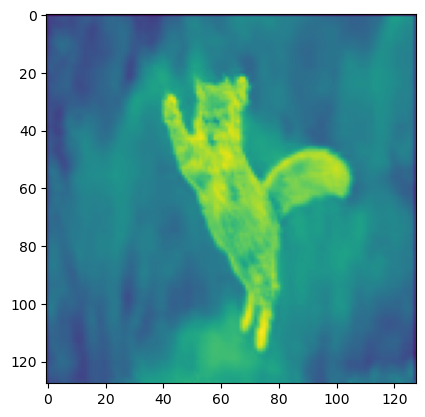

In [9]:
plt.imshow(y[0])